# Chapter 09: Levi-Civita Connection

Source orientation: printed pages 131-137; PDF pages 135-142. This notebook is original standalone course material built from the chapter's concepts and notation, not from copied source prose or figures.

## Chapter Goal

Build the Levi-Civita connection of an embedded surface as a computable operation: differentiate an ambient tangent vector field, split the result into tangent and normal parts, then verify that the tangent part is already determined by the first fundamental form. The chapter closes by using that connection to test Codazzi, Gauss, and Theorema Egregium residuals on an explicit surface patch. The repeated theme is that an ambient construction earns geometric meaning only after its tangent, metric, and curvature residuals agree.


## Computational Translation Guide

| Book object | Computational object | What we inspect |
|---|---|---|
| Surface map `f(u,v)` | Arrays for `f_u`, `f_v`, `f_uu`, `f_uv`, `f_vv` | Which part of an ambient derivative stays tangent. |
| Induced metric `g` | A `2 x 2` matrix field with entries `E,F,G` | Christoffel symbols computed from metric derivatives. |
| Levi-Civita connection `\nabla_X Y` | Coefficients `X^i(\partial_i Y^k + Gamma^k_{ij}Y^j)` | Metric compatibility and torsion-free residuals. |
| Shape operator `A` | Matrix `g^{-1}h` from the second fundamental form | Codazzi residual `(\nabla_u A)(v) - (\nabla_v A)(u)`. |
| Gauss equation | Curvature matrix of the connection | Difference from `-K det(u,v) J`. |
| Theorema Egregium | Metric-only symbolic curvature | Plane and cylinder have the same flat intrinsic curvature. |

Library routing: `numpy` carries the local tensor fields and residuals; `sympy` gives exact metric-only checks for plane, cylinder, and sphere metrics; `plotly` gives a rotatable 3D surface/frame artifact; `matplotlib` makes durable residual heatmaps; `networkx` records the proof dependencies without copying textbook layout.


In [1]:
from __future__ import annotations

from pathlib import Path
import sys

from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import plotly.graph_objects as go
import sympy as sp

BOOK_ROOT = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "00-book-index.ipynb").exists() and (candidate / "utils").exists():
        BOOK_ROOT = candidate
        break
if BOOK_ROOT is None:
    raise RuntimeError("Could not find the DGE-CWS book root")

if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import display_artifact, save_json, save_matplotlib, save_plotly_html
from utils.artifacts import ARTIFACT_ROOT
from utils.plotting import PALETTE, image_stats, style_axis

TOPIC = "chapter-09"
SOURCE_SPAN = {
    "printed_pages": "131-137",
    "pdf_pages": "135-142",
    "focus": "Tangential differentiation, Levi-Civita connection, Gauss and Codazzi equations, and Theorema Egregium.",
}

np.set_printoptions(precision=4, suppress=True)


## Refreshed Visual Storyboard

The chapter needs residuals, not decorative pictures. Each visual below has a measurement target.

1. **Tangent-normal derivative split**: show one ambient derivative of `df(Y)` and its tangent/normal parts at a point on a graph surface. Check that the projected tangent vector is orthogonal to the normal and reconstructs the ambient derivative.
2. **Christoffel coefficient comparison**: compare coefficients obtained by projecting `f_ij` onto the tangent basis with coefficients obtained from metric derivatives. Check that the two agree on the interior grid.
3. **Connection and curvature lab**: rotate a Plotly surface colored by Gaussian curvature, with a tangent frame and connection split at the same sample point.
4. **Gauss and Codazzi residual heatmaps**: compute `A`, `\nabla A`, the connection curvature matrix, and the source-sign Gauss residual. Check that both residuals are small away from finite-difference boundary rows.
5. **Egregium proof scaffold**: show how metric compatibility and torsion-free conditions determine the connection, then how the Gauss equation makes `K` intrinsic.


In [2]:
storyboard = {
    "chapter_goal": "Compute the surface Levi-Civita connection as tangential ambient differentiation and verify the intrinsic/extrinsic compatibility equations.",
    "source_span_read": SOURCE_SPAN,
    "library_routing": [
        {"concept": "tangent-normal split", "representation": "3D vector decomposition on a surface patch", "library": "matplotlib and plotly", "reason": "static artifact plus rotatable HTML inspection"},
        {"concept": "Christoffel symbols", "representation": "projection-vs-metric residual heatmap", "library": "numpy", "reason": "direct tensor arithmetic on a controlled surface grid"},
        {"concept": "Theorema Egregium", "representation": "exact metric curvature checks", "library": "sympy", "reason": "metric-only formulas should simplify exactly for model metrics"},
        {"concept": "Gauss/Codazzi", "representation": "connection and shape-operator residual fields", "library": "numpy and matplotlib", "reason": "residual heatmaps expose where identities are numerical rather than decorative"},
        {"concept": "proof dependencies", "representation": "directed dependency graph", "library": "networkx", "reason": "the Egregium proof is a dependency chain between metric, connection, and curvature"},
    ],
    "visual_sequence": [
        {"artifact": "figures/tangent-normal-derivative-split.png", "inspection_target": "ambient derivative equals tangent plus normal part"},
        {"artifact": "figures/metric-connection-coefficients.png", "inspection_target": "Christoffel symbols from metric match extrinsic projection"},
        {"artifact": "interactive/connection-and-curvature-lab.html", "inspection_target": "surface curvature and tangent frame can be rotated together"},
        {"artifact": "figures/gauss-codazzi-residuals.png", "inspection_target": "Gauss and Codazzi residuals are near zero in the interior"},
        {"artifact": "figures/egregium-proof-dependency.png", "inspection_target": "metric data determines the connection and hence Gaussian curvature"},
    ],
    "computational_checks": [
        "covariant derivative reconstruction residual",
        "metric projection Christoffel residual",
        "metric compatibility residual",
        "torsion-free residual",
        "Codazzi residual",
        "Gauss equation residual with the chapter sign convention",
        "plane/cylinder flatness and sphere K=1 from metric-only symbolic formulas",
        "artifact existence, size, and nonblank image statistics",
    ],
}
storyboard_path = save_json(storyboard, TOPIC, "checks", "visual-storyboard.json")
display(Markdown("Saved refreshed storyboard to `" + str(storyboard_path.relative_to(BOOK_ROOT)).replace("\\", "/") + "`."))
display_artifact(storyboard_path)


Saved refreshed storyboard to `artifacts/chapter-09/checks/visual-storyboard.json`.

## A Surface Patch With All Derivatives Visible

The source defines `\nabla_XY` by differentiating the ambient vector `df(Y)` and keeping only the tangent component. A graph surface is a useful laboratory because `f_u`, `f_v`, and the second derivatives are explicit, while the metric is not constant. That gives a nontrivial connection without hiding the construction behind a mesh package.

For `f(u,v)=(u,v,z(u,v))`, the tangent component of `f_ij` has coefficients `Gamma^k_ij`. We compute those coefficients two ways:

- **extrinsic projection**: solve `g Gamma_ij = (<f_ij,f_u>, <f_ij,f_v>)`;
- **metric formula**: use `Gamma^k_ij = 1/2 g^{k ell}(partial_i g_{j ell}+partial_j g_{i ell}-partial_ell g_{ij})`.

Their agreement is the computational version of Theorem 9.10: the same connection is determined by the metric.


In [3]:
AMP = 0.32
A_U = 0.65
A_V = 0.42
TWIST = 0.08


def graph_z(u, v, amplitude=AMP, au=A_U, av=A_V, twist=TWIST):
    q = np.exp(-(au * u * u + av * v * v))
    return amplitude * q + twist * u * v


def graph_derivatives(u, v, amplitude=AMP, au=A_U, av=A_V, twist=TWIST):
    q = np.exp(-(au * u * u + av * v * v))
    z = amplitude * q + twist * u * v
    zu = amplitude * q * (-2.0 * au * u) + twist * v
    zv = amplitude * q * (-2.0 * av * v) + twist * u
    zuu = amplitude * q * (4.0 * au * au * u * u - 2.0 * au)
    zvv = amplitude * q * (4.0 * av * av * v * v - 2.0 * av)
    zuv = amplitude * q * (4.0 * au * av * u * v) + twist
    return z, zu, zv, zuu, zuv, zvv


def surface_fields(n=121, extent=1.1, amplitude=AMP):
    u = np.linspace(-extent, extent, n)
    v = np.linspace(-extent, extent, n)
    U, V = np.meshgrid(u, v, indexing="ij")
    Z, Zu, Zv, Zuu, Zuv, Zvv = graph_derivatives(U, V, amplitude=amplitude)

    fu = np.stack([np.ones_like(U), np.zeros_like(U), Zu], axis=-1)
    fv = np.stack([np.zeros_like(U), np.ones_like(U), Zv], axis=-1)
    fuu = np.stack([np.zeros_like(U), np.zeros_like(U), Zuu], axis=-1)
    fuv = np.stack([np.zeros_like(U), np.zeros_like(U), Zuv], axis=-1)
    fvv = np.stack([np.zeros_like(U), np.zeros_like(U), Zvv], axis=-1)
    seconds = [[fuu, fuv], [fuv, fvv]]
    basis = [fu, fv]

    g = np.empty(U.shape + (2, 2))
    g[..., 0, 0] = np.einsum("...a,...a->...", fu, fu)
    g[..., 0, 1] = np.einsum("...a,...a->...", fu, fv)
    g[..., 1, 0] = g[..., 0, 1]
    g[..., 1, 1] = np.einsum("...a,...a->...", fv, fv)
    invg = np.linalg.inv(g)
    detg = np.linalg.det(g)
    area = np.sqrt(detg)
    normal = np.cross(fu, fv)
    normal = normal / np.linalg.norm(normal, axis=-1, keepdims=True)

    h = np.empty(U.shape + (2, 2))
    for i in range(2):
        for j in range(2):
            h[..., i, j] = np.einsum("...a,...a->...", seconds[i][j], normal)
    shape = np.einsum("...ki,...ij->...kj", invg, h)

    gamma_projection = np.zeros(U.shape + (2, 2, 2))
    for i in range(2):
        for j in range(2):
            rhs = np.stack([
                np.einsum("...a,...a->...", seconds[i][j], basis[0]),
                np.einsum("...a,...a->...", seconds[i][j], basis[1]),
            ], axis=-1)
            gamma_projection[..., :, i, j] = np.einsum("...kl,...l->...k", invg, rhs)

    du = float(u[1] - u[0])
    dv = float(v[1] - v[0])
    dg = np.empty(U.shape + (2, 2, 2))
    for i in range(2):
        for j in range(2):
            dg[..., 0, i, j] = np.gradient(g[..., i, j], du, axis=0, edge_order=2)
            dg[..., 1, i, j] = np.gradient(g[..., i, j], dv, axis=1, edge_order=2)

    gamma_metric = np.zeros_like(gamma_projection)
    for k in range(2):
        for i in range(2):
            for j in range(2):
                value = 0.0
                for ell in range(2):
                    value += invg[..., k, ell] * (dg[..., i, j, ell] + dg[..., j, i, ell] - dg[..., ell, i, j])
                gamma_metric[..., k, i, j] = 0.5 * value

    J = np.empty(U.shape + (2, 2))
    E = g[..., 0, 0]
    F = g[..., 0, 1]
    G = g[..., 1, 1]
    J[..., 0, 0] = -F / area
    J[..., 0, 1] = -G / area
    J[..., 1, 0] = E / area
    J[..., 1, 1] = F / area

    return {
        "u": u, "v": v, "U": U, "V": V, "Z": Z,
        "fu": fu, "fv": fv, "seconds": seconds, "g": g, "invg": invg,
        "detg": detg, "area": area, "normal": normal, "h": h, "shape": shape,
        "gamma_projection": gamma_projection, "gamma_metric": gamma_metric,
        "dg": dg, "du": du, "dv": dv, "J": J, "K": np.linalg.det(shape),
    }


def interior(array, margin=8):
    return array[margin:-margin, margin:-margin, ...]


fields = surface_fields()
display(Markdown(
    "Graph patch ready: metric determinant ranges from "
    f"`{fields['detg'].min():.4f}` to `{fields['detg'].max():.4f}`, so the sampled patch is regular."
))


Graph patch ready: metric determinant ranges from `1.0000` to `1.0837`, so the sampled patch is regular.

## Tangential Differentiation As A Split

At one point, choose a tangent direction `X` and a tangent field `Y`. The ambient derivative `d_X(df(Y))` is a vector in `R^3`, so it need not be tangent. The Levi-Civita derivative `\nabla_XY` is the coefficient vector whose embedded image is the tangent projection of that ambient derivative. The discarded normal component is the second fundamental form part.


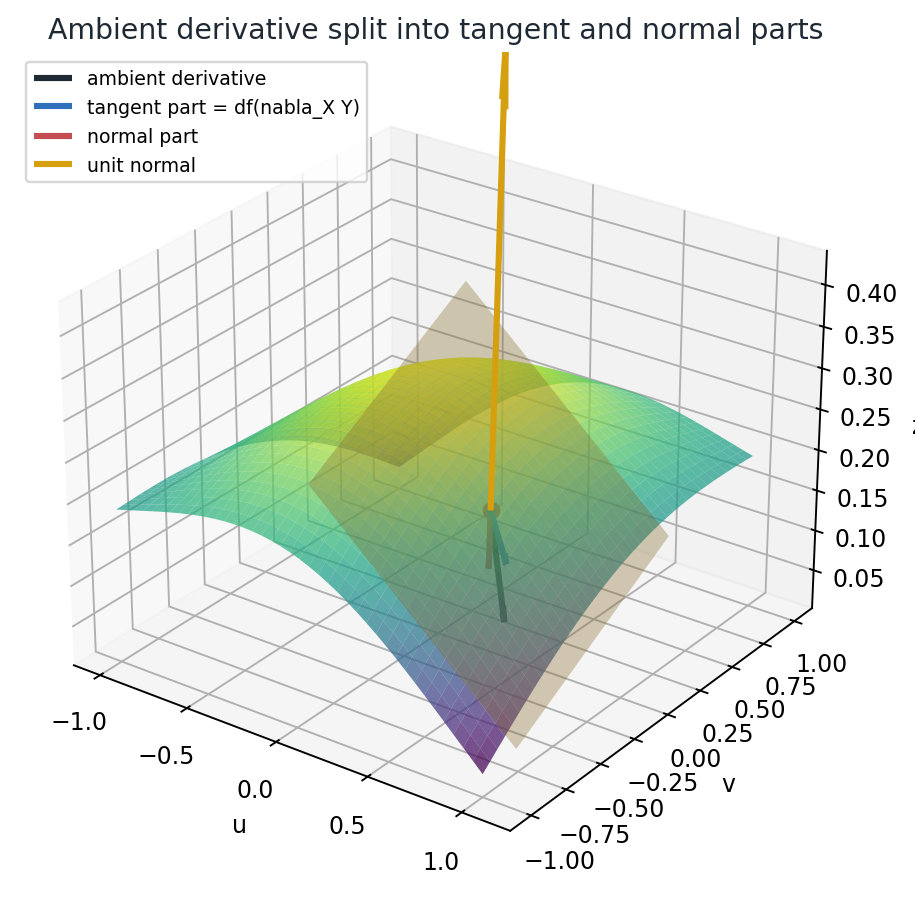

Split residuals: `tangent dot normal = 0.00e+00`, reconstruction error = `2.03e-17`.

In [4]:
def surface_point(u, v, amplitude=AMP):
    z, zu, zv, zuu, zuv, zvv = graph_derivatives(u, v, amplitude=amplitude)
    f = np.array([u, v, z], dtype=float)
    fu = np.array([1.0, 0.0, zu], dtype=float)
    fv = np.array([0.0, 1.0, zv], dtype=float)
    seconds = [[np.array([0.0, 0.0, zuu]), np.array([0.0, 0.0, zuv])], [np.array([0.0, 0.0, zuv]), np.array([0.0, 0.0, zvv])]]
    g = np.array([[fu @ fu, fu @ fv], [fu @ fv, fv @ fv]], dtype=float)
    invg = np.linalg.inv(g)
    normal = np.cross(fu, fv)
    normal = normal / np.linalg.norm(normal)
    gamma = np.zeros((2, 2, 2))
    for i in range(2):
        for j in range(2):
            rhs = np.array([seconds[i][j] @ fu, seconds[i][j] @ fv])
            gamma[:, i, j] = invg @ rhs
    return {"f": f, "fu": fu, "fv": fv, "seconds": seconds, "g": g, "normal": normal, "gamma": gamma}


def Y_coefficients(u, v):
    y = np.array([0.55 + 0.15 * np.sin(v) + 0.10 * u, -0.25 + 0.12 * np.cos(u) - 0.08 * v])
    yu = np.array([0.10, -0.12 * np.sin(u)])
    yv = np.array([0.15 * np.cos(v), -0.08])
    return y, [yu, yv]


def connection_split(u0=0.55, v0=-0.35, X=np.array([0.9, 0.45])):
    p = surface_point(u0, v0)
    y, dy = Y_coefficients(u0, v0)
    basis = [p["fu"], p["fv"]]
    ambient = np.zeros(3)
    nabla_coeff = np.zeros(2)
    for i in range(2):
        for j in range(2):
            ambient += X[i] * (dy[i][j] * basis[j] + y[j] * p["seconds"][i][j])
            for k in range(2):
                nabla_coeff[k] += X[i] * ((dy[i][k] if j == k else 0.0) + p["gamma"][k, i, j] * y[j])
    tangent = nabla_coeff[0] * p["fu"] + nabla_coeff[1] * p["fv"]
    normal_part = (ambient @ p["normal"]) * p["normal"]
    return p | {"u0": u0, "v0": v0, "X": X, "Y": y, "ambient": ambient, "nabla_coeff": nabla_coeff, "tangent": tangent, "normal_part": normal_part}


split = connection_split()
split_checks = {
    "tangent_normal_dot": float(abs(split["tangent"] @ split["normal"])),
    "ambient_reconstruction_error": float(np.linalg.norm(split["ambient"] - split["tangent"] - split["normal_part"])),
    "normal_part_norm": float(np.linalg.norm(split["normal_part"])),
    "nabla_coefficients": [float(x) for x in split["nabla_coeff"]],
}

u_grid = np.linspace(-1.0, 1.0, 40)
v_grid = np.linspace(-1.0, 1.0, 40)
U0, V0 = np.meshgrid(u_grid, v_grid, indexing="ij")
Z0 = graph_z(U0, V0)

fig = plt.figure(figsize=(9.0, 6.4))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(U0, V0, Z0, cmap="viridis", alpha=0.72, linewidth=0, antialiased=True)
plane_a = np.linspace(-0.55, 0.55, 8)
plane_b = np.linspace(-0.55, 0.55, 8)
AA, BB = np.meshgrid(plane_a, plane_b, indexing="ij")
plane = split["f"] + AA[..., None] * split["fu"] + BB[..., None] * split["fv"]
ax.plot_surface(plane[..., 0], plane[..., 1], plane[..., 2], color="#f2c14e", alpha=0.34, linewidth=0)

origin = split["f"]
for vec, color, label in [
    (split["ambient"], PALETTE["ink"], "ambient derivative"),
    (split["tangent"], PALETTE["blue"], "tangent part = df(nabla_X Y)"),
    (split["normal_part"], PALETTE["red"], "normal part"),
    (0.55 * split["normal"], PALETTE["gold"], "unit normal"),
]:
    vec = 0.9 * np.asarray(vec) if label != "unit normal" else np.asarray(vec)
    ax.quiver(origin[0], origin[1], origin[2], vec[0], vec[1], vec[2], color=color, linewidth=2.6, arrow_length_ratio=0.12, label=label)
ax.scatter([origin[0]], [origin[1]], [origin[2]], s=42, color=PALETTE["red"], depthshade=False)
ax.set_title("Ambient derivative split into tangent and normal parts", color=PALETTE["ink"])
ax.set_xlabel("u")
ax.set_ylabel("v")
ax.set_zlabel("z")
ax.view_init(elev=27, azim=-54)
ax.legend(loc="upper left", fontsize=8)

split_path = save_matplotlib(fig, TOPIC, "figures", "tangent-normal-derivative-split.png", dpi=170)
plt.close(fig)
display_artifact(split_path, width=760)
display(Markdown(
    "Split residuals: `tangent dot normal = "
    f"{split_checks['tangent_normal_dot']:.2e}`, reconstruction error = `{split_checks['ambient_reconstruction_error']:.2e}`."
))


## Christoffel Symbols From Metric Data

The metric compatibility identity

`partial_i g_{jk} = Gamma^ell_{ij} g_{ell k} + Gamma^ell_{ik} g_{j ell}`

and the torsion-free condition `Gamma^k_{uv}=Gamma^k_{vu}` characterize the Levi-Civita connection. The next diagnostic compares this intrinsic computation with the extrinsic tangent projection on the same grid.


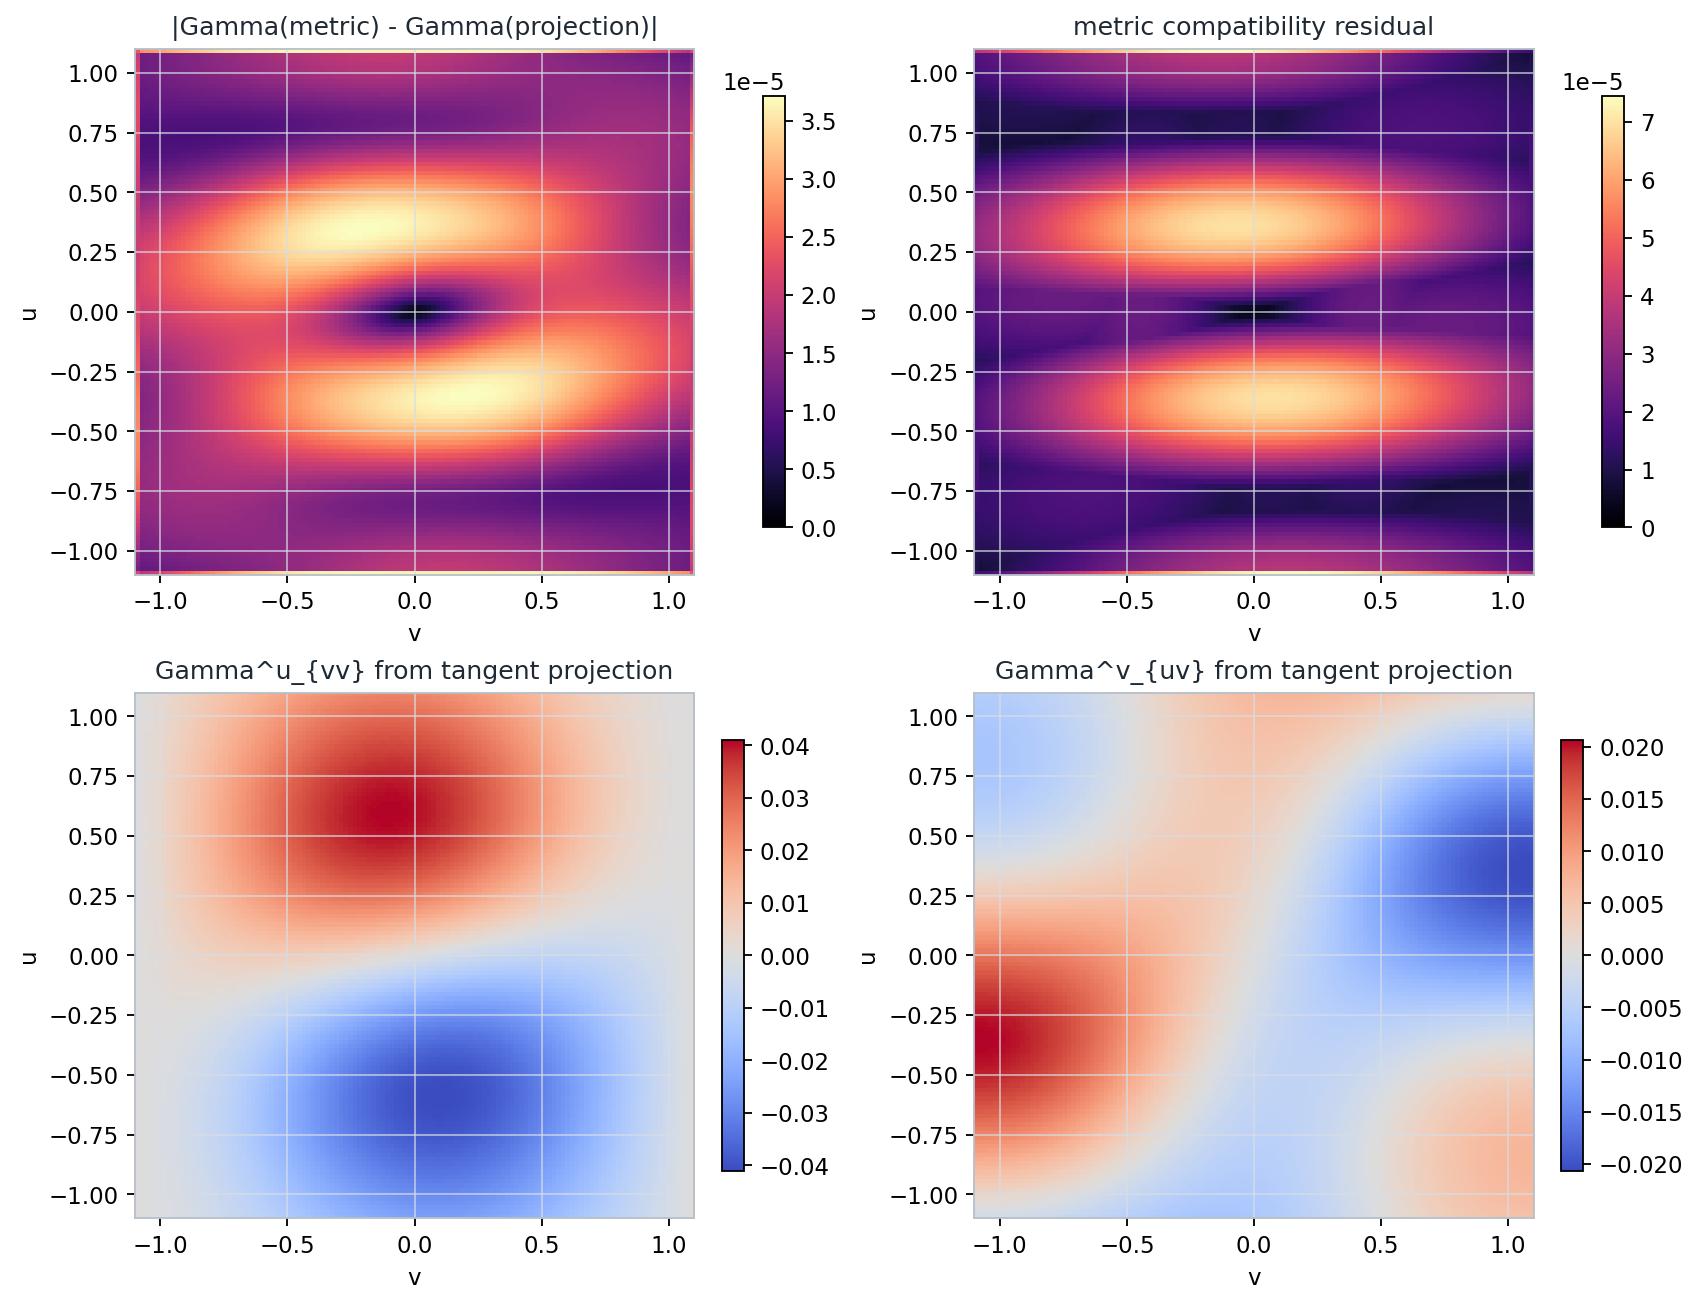

Interior residuals: `Gamma` comparison = `3.71e-05`, metric compatibility = `7.00e-05`, torsion-free = `0.00e+00`.

In [5]:
def connection_residuals(fields):
    gamma = fields["gamma_projection"]
    g = fields["g"]
    dg = fields["dg"]
    shape = fields["shape"]
    du = fields["du"]
    dv = fields["dv"]

    gamma_difference = np.sqrt(np.sum((fields["gamma_metric"] - gamma) ** 2, axis=(2, 3, 4)))
    torsion = np.linalg.norm(gamma[..., :, 0, 1] - gamma[..., :, 1, 0], axis=-1)

    compat_terms = []
    for i in range(2):
        for j in range(2):
            for k in range(2):
                value = dg[..., i, j, k].copy()
                for ell in range(2):
                    value -= gamma[..., ell, i, j] * g[..., ell, k] + gamma[..., ell, i, k] * g[..., j, ell]
                compat_terms.append(value)
    metric_compatibility = np.max(np.abs(np.stack(compat_terms, axis=-1)), axis=-1)

    dshape = np.empty(shape.shape[:2] + (2, 2, 2))
    for k in range(2):
        for j in range(2):
            dshape[..., 0, k, j] = np.gradient(shape[..., k, j], du, axis=0, edge_order=2)
            dshape[..., 1, k, j] = np.gradient(shape[..., k, j], dv, axis=1, edge_order=2)

    cov_shape = np.zeros_like(dshape)
    for i in range(2):
        for k in range(2):
            for j in range(2):
                value = dshape[..., i, k, j].copy()
                for ell in range(2):
                    value += gamma[..., k, i, ell] * shape[..., ell, j] - gamma[..., ell, i, j] * shape[..., k, ell]
                cov_shape[..., i, k, j] = value
    codazzi_vector = cov_shape[..., 0, :, 1] - cov_shape[..., 1, :, 0]
    codazzi_norm = np.linalg.norm(codazzi_vector, axis=-1)

    dgamma = np.empty(gamma.shape[:2] + (2, 2, 2, 2))
    for k in range(2):
        for i in range(2):
            for j in range(2):
                dgamma[..., 0, k, i, j] = np.gradient(gamma[..., k, i, j], du, axis=0, edge_order=2)
                dgamma[..., 1, k, i, j] = np.gradient(gamma[..., k, i, j], dv, axis=1, edge_order=2)

    curvature_matrix = np.zeros(gamma.shape[:2] + (2, 2))
    for k in range(2):
        for ell in range(2):
            value = dgamma[..., 0, k, 1, ell] - dgamma[..., 1, k, 0, ell]
            for m in range(2):
                value += gamma[..., k, 0, m] * gamma[..., m, 1, ell] - gamma[..., k, 1, m] * gamma[..., m, 0, ell]
            curvature_matrix[..., k, ell] = value

    gauss_target = -fields["K"][..., None, None] * fields["area"][..., None, None] * fields["J"]
    gauss_norm = np.linalg.norm(curvature_matrix - gauss_target, axis=(2, 3))
    K_from_connection = curvature_matrix[..., 0, 1] / fields["g"][..., 1, 1]
    K_difference = np.abs(K_from_connection - fields["K"])

    scalars = {
        "christoffel_projection_metric_max": float(np.max(interior(gamma_difference))),
        "metric_compatibility_max": float(np.max(interior(metric_compatibility))),
        "torsion_free_max": float(np.max(interior(torsion))),
        "codazzi_residual_max": float(np.max(interior(codazzi_norm))),
        "codazzi_residual_mean": float(np.mean(interior(codazzi_norm))),
        "gauss_equation_residual_max": float(np.max(interior(gauss_norm))),
        "gauss_equation_residual_mean": float(np.mean(interior(gauss_norm))),
        "K_connection_shape_max_difference": float(np.max(interior(K_difference))),
        "K_shape_min": float(np.min(interior(fields["K"]))),
        "K_shape_max": float(np.max(interior(fields["K"]))),
    }
    arrays = {
        "gamma_difference": gamma_difference,
        "metric_compatibility": metric_compatibility,
        "torsion": torsion,
        "codazzi_norm": codazzi_norm,
        "gauss_norm": gauss_norm,
        "K_from_connection": K_from_connection,
        "K_difference": K_difference,
    }
    return scalars, arrays


residual_scalars, residual_arrays = connection_residuals(fields)

fig, axes = plt.subplots(2, 2, figsize=(10.2, 7.8), constrained_layout=True)
extent = [fields["v"][0], fields["v"][-1], fields["u"][0], fields["u"][-1]]
plots = [
    (residual_arrays["gamma_difference"], "|Gamma(metric) - Gamma(projection)|"),
    (residual_arrays["metric_compatibility"], "metric compatibility residual"),
    (fields["gamma_projection"][..., 0, 1, 1], "Gamma^u_{vv} from tangent projection"),
    (fields["gamma_projection"][..., 1, 0, 1], "Gamma^v_{uv} from tangent projection"),
]
for ax, (data, title) in zip(axes.ravel(), plots):
    cmap = "magma" if "residual" in title or "Gamma(metric)" in title else "coolwarm"
    im = ax.imshow(data, origin="lower", extent=extent, cmap=cmap, aspect="auto")
    ax.set_xlabel("v")
    ax.set_ylabel("u")
    style_axis(ax, title)
    fig.colorbar(im, ax=ax, shrink=0.82)

metric_path = save_matplotlib(fig, TOPIC, "figures", "metric-connection-coefficients.png", dpi=165)
plt.close(fig)
display_artifact(metric_path, width=820)

display(Markdown(
    "Interior residuals: `Gamma` comparison = "
    f"`{residual_scalars['christoffel_projection_metric_max']:.2e}`, metric compatibility = "
    f"`{residual_scalars['metric_compatibility_max']:.2e}`, torsion-free = `{residual_scalars['torsion_free_max']:.2e}`."
))


## Interactive Connection And Curvature Lab

Rotate the HTML artifact and compare three local objects: the surface color is Gaussian curvature, the gold sheet is the tangent plane at the sample point, and the three arrows show ambient derivative, tangent projection, and normal part. Changing the graph amplitude later changes the visible curvature but should not break the connection identities.


In [6]:
stride = 2
U = fields["U"][::stride, ::stride]
V = fields["V"][::stride, ::stride]
Z = fields["Z"][::stride, ::stride]
K = fields["K"][::stride, ::stride]

fig3 = go.Figure()
fig3.add_trace(go.Surface(
    x=U, y=V, z=Z, surfacecolor=K, colorscale="RdBu", reversescale=True,
    colorbar={"title": "K"}, name="surface colored by K", opacity=0.92,
))
plane = split["f"] + np.linspace(-0.5, 0.5, 9)[:, None, None] * split["fu"] + np.linspace(-0.5, 0.5, 9)[None, :, None] * split["fv"]
fig3.add_trace(go.Surface(
    x=plane[..., 0], y=plane[..., 1], z=plane[..., 2], showscale=False,
    opacity=0.38, colorscale=[[0, "#f2c14e"], [1, "#f2c14e"]], name="tangent plane",
))
for vec, name, color in [
    (split["ambient"], "ambient derivative", PALETTE["ink"]),
    (split["tangent"], "tangent projection", PALETTE["blue"]),
    (split["normal_part"], "normal part", PALETTE["red"]),
    (0.55 * split["normal"], "unit normal", PALETTE["gold"]),
]:
    end = split["f"] + np.asarray(vec, dtype=float)
    fig3.add_trace(go.Scatter3d(
        x=[split["f"][0], end[0]], y=[split["f"][1], end[1]], z=[split["f"][2], end[2]],
        mode="lines+markers", marker={"size": 3}, line={"width": 7, "color": color}, name=name,
    ))
fig3.update_layout(
    title="Levi-Civita connection: tangent projection on a curved graph patch",
    height=620,
    scene={"aspectmode": "data", "xaxis_title": "u", "yaxis_title": "v", "zaxis_title": "z"},
    legend={"orientation": "h", "y": 0.02},
    margin={"l": 0, "r": 0, "t": 55, "b": 0},
)
interactive_path = save_plotly_html(fig3, TOPIC, "interactive", "connection-and-curvature-lab.html")
display_artifact(interactive_path, height=520)


## Gauss And Codazzi As Residual Equations

The chapter's extrinsic equations are now testable on the same patch.

- **Codazzi** checks whether the covariant derivative of the shape operator is symmetric: `(\nabla_u A)(v) - (\nabla_v A)(u) = 0`.
- **Gauss** checks whether the curvature of the Levi-Civita connection is exactly the rotation operator predicted by Gaussian curvature: `R(u,v) = -K det(u,v) J`, using the source's sign convention for `J`.

The heatmaps are not proof, but they are a useful debugger. Large boundary values usually indicate finite-difference edge effects; large interior values indicate a wrong sign, a non-torsion-free connection, or a shape operator computed with inconsistent metric data.


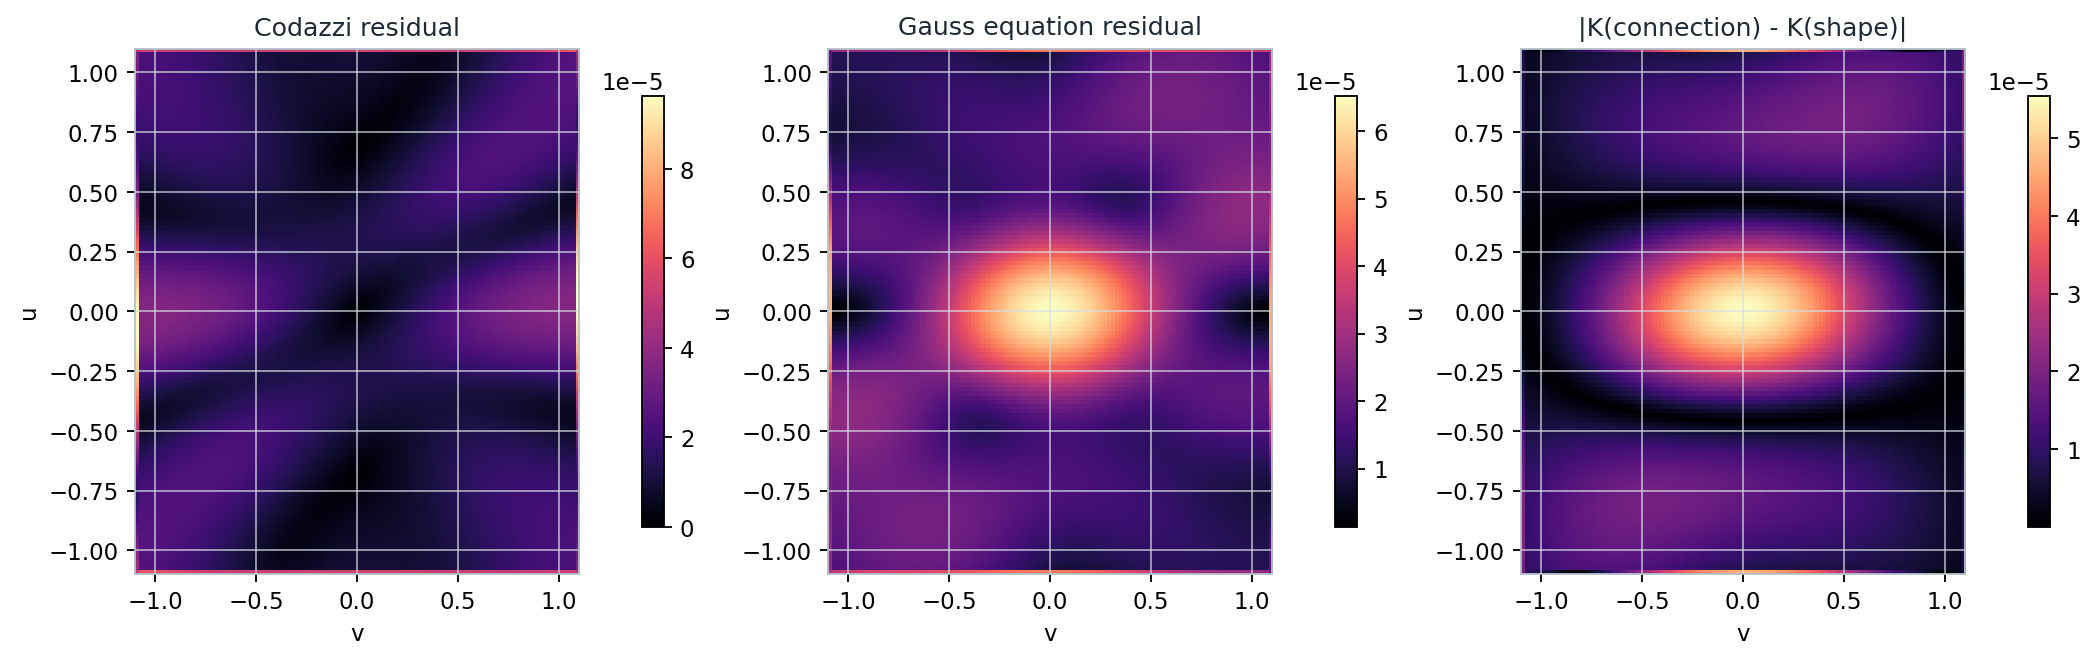

Interior residuals: Codazzi max = `3.62e-05`, Gauss max = `6.52e-05`, `K` from connection vs shape = `5.54e-05`.

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(12.6, 3.9), constrained_layout=True)
heatmaps = [
    (residual_arrays["codazzi_norm"], "Codazzi residual"),
    (residual_arrays["gauss_norm"], "Gauss equation residual"),
    (residual_arrays["K_difference"], "|K(connection) - K(shape)|"),
]
for ax, (data, title) in zip(axes, heatmaps):
    im = ax.imshow(data, origin="lower", extent=extent, cmap="magma", aspect="auto")
    ax.set_xlabel("v")
    ax.set_ylabel("u")
    style_axis(ax, title)
    fig.colorbar(im, ax=ax, shrink=0.82)

gauss_codazzi_path = save_matplotlib(fig, TOPIC, "figures", "gauss-codazzi-residuals.png", dpi=165)
plt.close(fig)
display_artifact(gauss_codazzi_path, width=860)

display(Markdown(
    "Interior residuals: Codazzi max = "
    f"`{residual_scalars['codazzi_residual_max']:.2e}`, Gauss max = "
    f"`{residual_scalars['gauss_equation_residual_max']:.2e}`, `K` from connection vs shape = "
    f"`{residual_scalars['K_connection_shape_max_difference']:.2e}`."
))


## Metric-Only Checks For Theorema Egregium

The Theorema Egregium proof in the chapter has a short dependency chain: if the metric determines the Levi-Civita connection, and the Gauss equation reads Gaussian curvature from that connection, then an isometry preserves `K`. The next symbolic check computes curvature from the metric alone for three model metrics.

The plane and a unit cylinder written in coordinates `(u,v)` both have metric `du^2 + dv^2`, so their connection coefficients and Gaussian curvature vanish. A radius-`R` cylinder has constant metric `R^2 du^2 + dv^2` and still has zero intrinsic curvature. The round sphere metric `du^2 + sin^2(u)dv^2` has nonzero Christoffel symbols and metric curvature `K=1`.


In [8]:
def sympy_christoffel(metric, coords):
    inv_metric = metric.inv()
    dim = len(coords)
    gamma = [[[sp.Integer(0) for _ in range(dim)] for _ in range(dim)] for _ in range(dim)]
    for k in range(dim):
        for i in range(dim):
            for j in range(dim):
                value = sp.Integer(0)
                for ell in range(dim):
                    value += inv_metric[k, ell] * (
                        sp.diff(metric[j, ell], coords[i])
                        + sp.diff(metric[i, ell], coords[j])
                        - sp.diff(metric[i, j], coords[ell])
                    )
                gamma[k][i][j] = sp.simplify(value / 2)
    return gamma


def sympy_curvature_matrix(gamma, coords):
    dim = len(coords)
    R = sp.MutableDenseMatrix.zeros(dim, dim)
    for k in range(dim):
        for ell in range(dim):
            value = sp.diff(gamma[k][1][ell], coords[0]) - sp.diff(gamma[k][0][ell], coords[1])
            for m in range(dim):
                value += gamma[k][0][m] * gamma[m][1][ell] - gamma[k][1][m] * gamma[m][0][ell]
            R[k, ell] = sp.simplify(value)
    return sp.Matrix(R)


def metric_gaussian_curvature(metric, coords):
    gamma = sympy_christoffel(metric, coords)
    R = sympy_curvature_matrix(gamma, coords)
    K = sp.simplify(R[0, 1] / metric.det())
    return gamma, R, K


u, v, R_radius = sp.symbols("u v R", positive=True)
coords = (u, v)
plane_metric = sp.diag(1, 1)
cylinder_metric = sp.diag(R_radius**2, 1)
sphere_metric = sp.diag(1, sp.sin(u) ** 2)

plane_gamma, plane_R, plane_K = metric_gaussian_curvature(plane_metric, coords)
cylinder_gamma, cylinder_R, cylinder_K = metric_gaussian_curvature(cylinder_metric, coords)
sphere_gamma, sphere_R, sphere_K = metric_gaussian_curvature(sphere_metric, coords)

symbolic_checks = {
    "plane_metric": "diag(1, 1)",
    "plane_K_from_metric": str(plane_K),
    "cylinder_metric": "diag(R^2, 1)",
    "cylinder_K_from_metric": str(cylinder_K),
    "sphere_metric": "diag(1, sin(u)^2)",
    "sphere_Gamma_u_vv": str(sphere_gamma[0][1][1]),
    "sphere_Gamma_v_uv": str(sphere_gamma[1][0][1]),
    "sphere_K_from_metric": str(sphere_K),
}
assert sp.simplify(plane_K) == 0
assert sp.simplify(cylinder_K) == 0
assert sp.simplify(sphere_K - 1) == 0

symbolic_path = save_json(symbolic_checks, TOPIC, "checks", "symbolic-egregium-checks.json")
rows = ["| Metric | Nonzero connection data | K from metric |", "|---|---|---|"]
rows.append("| plane `diag(1,1)` | none | `0` |")
rows.append("| cylinder `diag(R^2,1)` | none | `0` |")
rows.append("| sphere `diag(1,sin(u)^2)` | `Gamma^u_vv=-sin(u)cos(u)`, `Gamma^v_uv=cot(u)` | `1` |")
display(Markdown("\n".join(rows)))
display_artifact(symbolic_path)


| Metric | Nonzero connection data | K from metric |
|---|---|---|
| plane `diag(1,1)` | none | `0` |
| cylinder `diag(R^2,1)` | none | `0` |
| sphere `diag(1,sin(u)^2)` | `Gamma^u_vv=-sin(u)cos(u)`, `Gamma^v_uv=cot(u)` | `1` |

## Proof Dependency Scaffold

The dependency graph below keeps the logic visible. The metric gives inner products and area rotation `J`. Metric compatibility plus torsion-free equations determine the connection coefficients. The Gauss equation then expresses connection curvature using `K`. That is the point of Theorema Egregium: an isometry has the same metric, hence the same connection, hence the same Gaussian curvature.


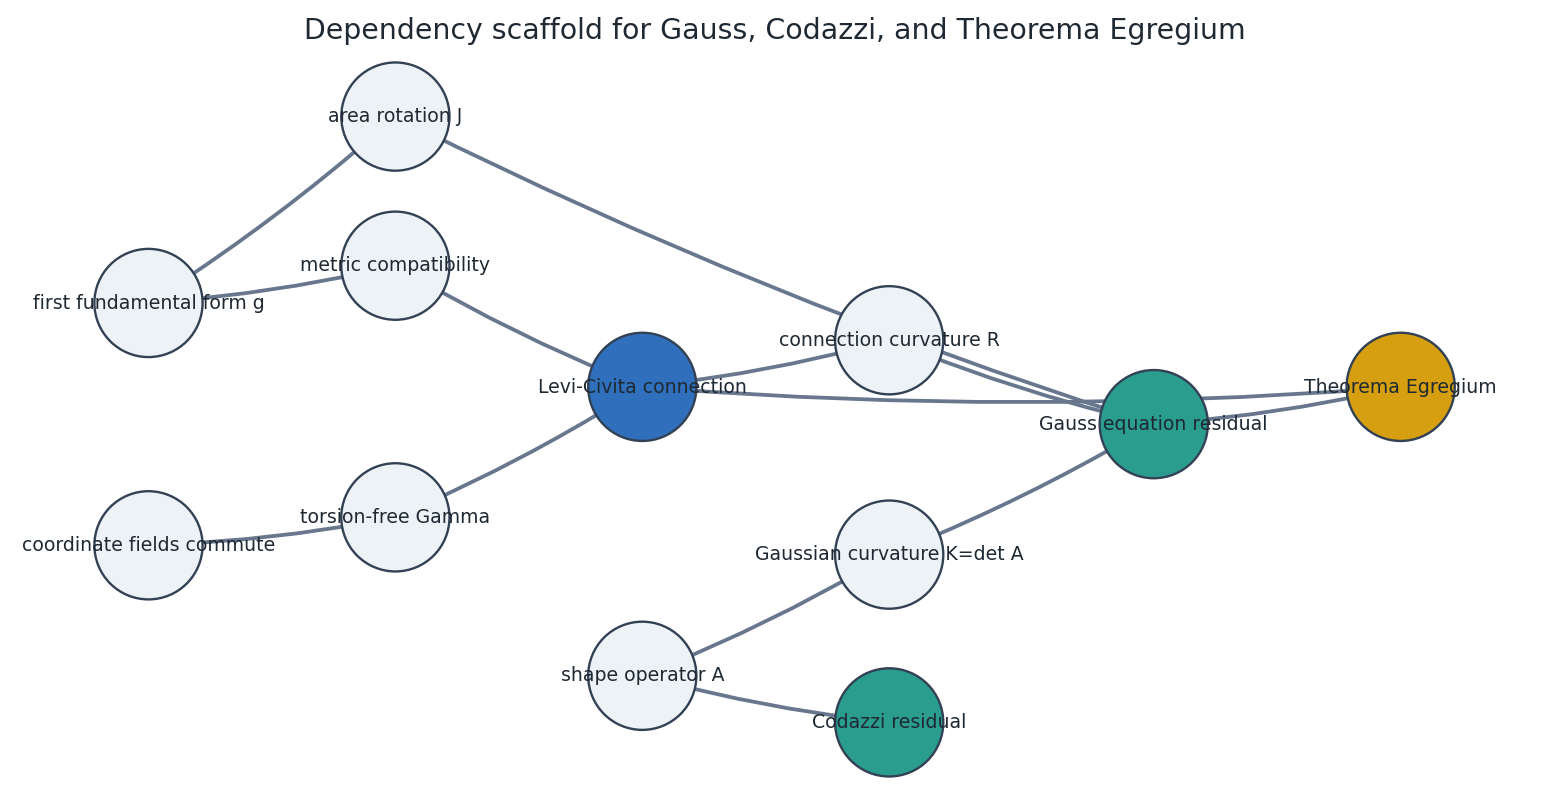

In [9]:
Gproof = nx.DiGraph()
Gproof.add_edges_from([
    ("first fundamental form g", "metric compatibility"),
    ("first fundamental form g", "area rotation J"),
    ("coordinate fields commute", "torsion-free Gamma"),
    ("metric compatibility", "Levi-Civita connection"),
    ("torsion-free Gamma", "Levi-Civita connection"),
    ("Levi-Civita connection", "connection curvature R"),
    ("shape operator A", "Codazzi residual"),
    ("shape operator A", "Gaussian curvature K=det A"),
    ("connection curvature R", "Gauss equation residual"),
    ("area rotation J", "Gauss equation residual"),
    ("Gaussian curvature K=det A", "Gauss equation residual"),
    ("Gauss equation residual", "Theorema Egregium"),
    ("Levi-Civita connection", "Theorema Egregium"),
])
pos = {
    "first fundamental form g": (0.0, 1.0),
    "coordinate fields commute": (0.0, -0.3),
    "metric compatibility": (1.4, 1.2),
    "torsion-free Gamma": (1.4, -0.15),
    "Levi-Civita connection": (2.8, 0.55),
    "area rotation J": (1.4, 2.0),
    "shape operator A": (2.8, -1.0),
    "Codazzi residual": (4.2, -1.25),
    "Gaussian curvature K=det A": (4.2, -0.35),
    "connection curvature R": (4.2, 0.8),
    "Gauss equation residual": (5.7, 0.35),
    "Theorema Egregium": (7.1, 0.55),
}
fig, ax = plt.subplots(figsize=(11.5, 5.6))
node_colors = [
    PALETTE["teal"] if "residual" in n else PALETTE["blue"] if n == "Levi-Civita connection" else PALETTE["gold"] if "Egregium" in n else "#edf2f7"
    for n in Gproof.nodes
]
nx.draw_networkx_edges(Gproof, pos, ax=ax, arrows=True, arrowstyle="-|>", arrowsize=14, width=1.6, edge_color="#68778d", connectionstyle="arc3,rad=0.04")
nx.draw_networkx_nodes(Gproof, pos, ax=ax, node_color=node_colors, edgecolors="#334155", linewidths=1.0, node_size=2100)
nx.draw_networkx_labels(Gproof, pos, ax=ax, font_size=8, font_color=PALETTE["ink"])
ax.set_title("Dependency scaffold for Gauss, Codazzi, and Theorema Egregium", color=PALETTE["ink"])
ax.axis("off")
proof_path = save_matplotlib(fig, TOPIC, "figures", "egregium-proof-dependency.png", dpi=170)
plt.close(fig)
display_artifact(proof_path, width=860)


## Applied Lab: Change The Graph, Keep The Identities

The lab changes the graph amplitude. Curvature changes visibly and numerically, but the Levi-Civita identities are structural: metric compatibility, Codazzi, and Gauss residuals should stay small on the interior grid. If a residual grows, the first debugging questions are whether the finite-difference margin is too small, whether the sign convention for `J` was changed, or whether the shape operator was formed with a metric from a different surface.


In [10]:
lab_rows = []
for amplitude in [0.18, 0.32, 0.50]:
    lab_fields = surface_fields(n=101, extent=1.0, amplitude=amplitude)
    lab_scalars, _ = connection_residuals(lab_fields)
    lab_rows.append({
        "amplitude": amplitude,
        "K_min": lab_scalars["K_shape_min"],
        "K_max": lab_scalars["K_shape_max"],
        "Gamma_residual": lab_scalars["christoffel_projection_metric_max"],
        "Codazzi_residual": lab_scalars["codazzi_residual_max"],
        "Gauss_residual": lab_scalars["gauss_equation_residual_max"],
    })

lab_table = ["| amplitude | K min | K max | Gamma residual | Codazzi residual | Gauss residual |", "|---:|---:|---:|---:|---:|---:|"]
for row in lab_rows:
    lab_table.append(
        f"| {row['amplitude']:.2f} | {row['K_min']:.3f} | {row['K_max']:.3f} | "
        f"{row['Gamma_residual']:.2e} | {row['Codazzi_residual']:.2e} | {row['Gauss_residual']:.2e} |"
    )
display(Markdown("\n".join(lab_table)))


| amplitude | K min | K max | Gamma residual | Codazzi residual | Gauss residual |
|---:|---:|---:|---:|---:|---:|
| 0.18 | -0.021 | 0.029 | 1.54e-05 | 1.80e-05 | 2.28e-05 |
| 0.32 | -0.037 | 0.105 | 4.42e-05 | 4.15e-05 | 7.76e-05 |
| 0.50 | -0.060 | 0.267 | 1.02e-04 | 9.47e-05 | 2.19e-04 |

## Final Sanity Checks And Takeaways

The final checks are deliberately narrow and chapter-specific. They assert the projection definition of `\nabla`, the metric characterization of Christoffel symbols, the torsion-free and metric-compatibility identities, the Gauss/Codazzi residuals, the exact metric-only Egregium examples, and the existence/nonblank status of every visual artifact used above.

Takeaways:

- The Levi-Civita connection is the tangent part of ambient differentiation, not a new ambient vector field.
- The same coefficients can be recovered from the metric alone; this is why isometric surfaces share a connection.
- Codazzi tests compatibility of the shape operator with the connection.
- The Gauss equation turns Gaussian curvature into connection curvature, making `K` intrinsic despite being introduced from the shape operator.


In [11]:
numeric_checks = {
    **split_checks,
    **residual_scalars,
    "plane_K_from_metric": str(plane_K),
    "cylinder_K_from_metric": str(cylinder_K),
    "sphere_K_from_metric": str(sphere_K),
    "lab_rows": lab_rows,
}

assert numeric_checks["tangent_normal_dot"] < 1e-12
assert numeric_checks["ambient_reconstruction_error"] < 1e-12
assert numeric_checks["christoffel_projection_metric_max"] < 5e-4
assert numeric_checks["metric_compatibility_max"] < 5e-4
assert numeric_checks["torsion_free_max"] < 1e-12
assert numeric_checks["codazzi_residual_max"] < 5e-4
assert numeric_checks["gauss_equation_residual_max"] < 5e-4
assert numeric_checks["K_connection_shape_max_difference"] < 5e-4
assert sp.simplify(plane_K) == 0
assert sp.simplify(cylinder_K) == 0
assert sp.simplify(sphere_K - 1) == 0
for row in lab_rows:
    assert row["Gamma_residual"] < 8e-4
    assert row["Codazzi_residual"] < 8e-4
    assert row["Gauss_residual"] < 8e-4

numeric_path = save_json(numeric_checks, TOPIC, "checks", "numeric-checks.json")
display_artifact(numeric_path)


In [12]:
artifact_paths = [
    storyboard_path,
    split_path,
    metric_path,
    interactive_path,
    gauss_codazzi_path,
    symbolic_path,
    proof_path,
    numeric_path,
]

final_sanity = {}
for artifact in artifact_paths:
    assert artifact.exists(), artifact
    assert artifact.stat().st_size > 1000 or artifact.suffix == ".json", artifact
    key = str(artifact.relative_to(BOOK_ROOT)).replace("\\", "/")
    final_sanity[key] = {"bytes": int(artifact.stat().st_size)}
    if artifact.suffix.lower() == ".png":
        stats = image_stats(artifact)
        assert stats["pixel_std"] > 1.0, artifact
        final_sanity[key].update({
            "width": int(stats["width"]),
            "height": int(stats["height"]),
            "pixel_std": float(stats["pixel_std"]),
        })

final_sanity_path = save_json(final_sanity, TOPIC, "checks", "final-sanity.json")
assert final_sanity_path.exists()
assert final_sanity_path.stat().st_size > 1000
display_artifact(final_sanity_path)
